# Seller Analysis

This section examines seller performance, sales volume, and revenue contribution.

In [5]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/raw")

sellers = pd.read_csv(
    DATA_DIR / "olist_sellers_dataset.csv"
)

order_items = pd.read_csv(
    DATA_DIR / "olist_order_items_dataset.csv"
)

In [6]:
sellers.shape

(3095, 4)

In [7]:
order_items.shape

(112650, 7)

In [8]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [9]:
order_items["seller_id"].nunique()

3095

In [10]:
order_items["order_id"].nunique()

98666

In [11]:
order_items["order_id"].nunique() / len(order_items)

0.8758632933865956

In [12]:
order_items.groupby("order_id")["seller_id"].nunique().value_counts().sort_index()

seller_id
1    97388
2     1219
3       54
4        3
5        2
Name: count, dtype: int64

In [13]:
order_items[["price", "freight_value"]].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [15]:
orders = pd.read_csv(
    DATA_DIR / "olist_orders_dataset.csv"
)

In [16]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [17]:
delivered_order_ids = orders.loc[
    orders["order_status"] == "delivered",
    "order_id"
]

delivered_items = order_items[
    order_items["order_id"].isin(delivered_order_ids)
].copy()

delivered_items.shape

(110197, 7)

In [18]:
delivered_items["seller_id"].nunique()

2970

In [19]:
len(set(sellers["seller_id"]) - set(delivered_items["seller_id"]))

125

In [20]:
seller_performance = (
    delivered_items
    .groupby("seller_id")
    .agg(
        orders=("order_id", "nunique"),
        items_sold=("order_id", "count"),
        revenue=("price", "sum")
    )
)

seller_performance["avg_order_value"] = (
    seller_performance["revenue"]
    / seller_performance["orders"]
)

seller_performance = seller_performance.reset_index()

seller_performance.head()

,seller_id,orders,items_sold,revenue,avg_order_value
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,2685.00,895.000000
1,001cca7ae9ae17fb1caed9dfb1094831,195,234,24487.03,125.574513
2,002100f778ceb8431b7a1020ff7ab48f,50,54,1216.60,24.332000
3,003554e2dce176b5555353e4f3555ac8,1,1,120.00,120.000000
4,004c9cd9d87a3c30c522c48c4fc07416,156,168,19569.73,125.446987


In [21]:
seller_performance[
    ["orders", "items_sold", "revenue", "avg_order_value"]
].describe()

,orders,items_sold,revenue,avg_order_value
count,2970.000000,2970.000000,2970.000000,2970.000000
mean,32.935690,37.103367,4451.682865,195.520629
std,105.407111,119.672968,13926.965314,368.473461
min,1.000000,1.000000,6.500000,6.000000
25%,2.000000,2.000000,219.800000,60.075000
50%,7.000000,8.000000,846.175000,105.143844
75%,22.000000,26.000000,3497.880000,187.583944
max,1819.000000,1996.000000,226987.930000,6735.000000


In [22]:
seller_performance.sort_values(
    "revenue",
    ascending=False
).head(10)

,seller_id,orders,items_sold,revenue,avg_order_value
834,4869f7a5dfa277a7dca6462dcf3b52b2,1124,1148,226987.93,201.946557
982,53243585a1d6dc2643021fd1853d8905,348,400,217940.44,626.265632
858,4a3ca9315b744ce9f8e9374361493884,1772,1949,196882.12,111.107291
2903,fa1c13f2614d7b5c4749cbc52fecda94,578,579,190917.14,330.306471
1480,7c67e1448b00f6e969d365cea6b010ab,973,1355,186570.05,191.747225
1504,7e93a43ef30c4f03f38b393420bc753a,319,322,165981.49,520.318150
2543,da8622b14eb17ae2831f4ac5b9dab84a,1311,1548,159816.87,121.904554
1450,7a67c85e85bb2ce8582c35f2203ad736,1145,1155,139658.69,121.972655
188,1025f0e2d44d7041d6cf58b6550e0bfa,910,1420,138208.56,151.877538
1758,955fee9216a65b617aa5c0531780ce60,1261,1472,131836.71,104.549334


In [23]:
top_10_revenue_share = (
    seller_performance
    .nlargest(10, "revenue")["revenue"]
    .sum()
    / seller_performance["revenue"].sum()
)

top_10_revenue_share

np.float64(0.13272323494663343)

In [24]:
top_1_revenue_share = (
    seller_performance
    .nlargest(1, "revenue")["revenue"]
    .sum()
    / seller_performance["revenue"].sum()
)

top_25_revenue_share = (
    seller_performance
    .nlargest(25, "revenue")["revenue"]
    .sum()
    / seller_performance["revenue"].sum()
)

top_1_revenue_share, top_10_revenue_share, top_25_revenue_share

(np.float64(0.017168094576840657),
 np.float64(0.13272323494663343),
 np.float64(0.2380728419587544))

In [25]:
seller_revenue_curve = seller_performance.sort_values(
    "revenue",
    ascending=False
).reset_index(drop=True)

seller_revenue_curve["cumulative_revenue_share"] = (
    seller_revenue_curve["revenue"].cumsum()
    / seller_revenue_curve["revenue"].sum()
)

seller_revenue_curve["seller_share"] = (
    (seller_revenue_curve.index + 1)
    / len(seller_revenue_curve)
)

seller_revenue_curve.head()

,seller_id,orders,items_sold,revenue,avg_order_value,cumulative_revenue_share,seller_share
0,4869f7a5dfa277a7dca6462dcf3b52b2,1124,1148,226987.93,201.946557,0.017168,0.000337
1,53243585a1d6dc2643021fd1853d8905,348,400,217940.44,626.265632,0.033652,0.000673
2,4a3ca9315b744ce9f8e9374361493884,1772,1949,196882.12,111.107291,0.048543,0.001010
3,fa1c13f2614d7b5c4749cbc52fecda94,578,579,190917.14,330.306471,0.062983,0.001347
4,7c67e1448b00f6e969d365cea6b010ab,973,1355,186570.05,191.747225,0.077094,0.001684


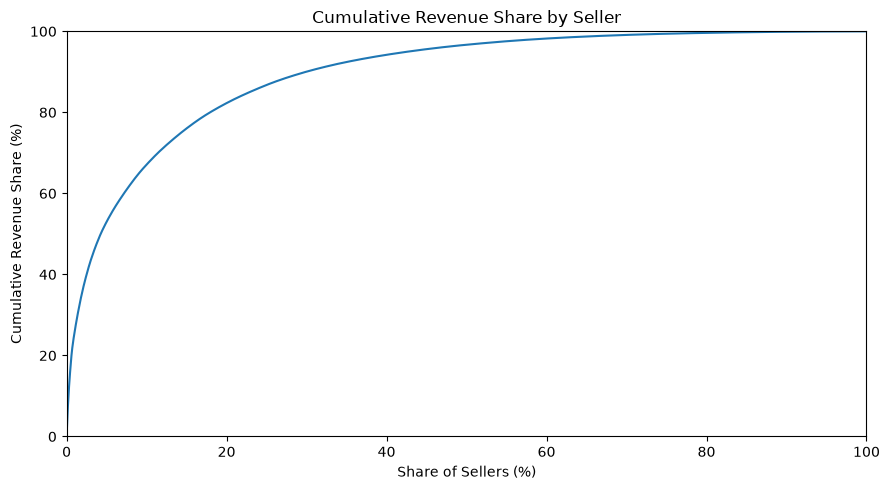

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    seller_revenue_curve["seller_share"] * 100,
    seller_revenue_curve["cumulative_revenue_share"] * 100
)

plt.title("Cumulative Revenue Share by Seller")
plt.xlabel("Share of Sellers (%)")
plt.ylabel("Cumulative Revenue Share (%)")

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [27]:
seller_performance[
    ["orders", "revenue"]
].corr()

,orders,revenue
orders,1.000000,0.800656
revenue,0.800656,1.000000


In [28]:
seller_performance[
    ["orders", "revenue"]
].describe()

,orders,revenue
count,2970.000000,2970.000000
mean,32.935690,4451.682865
std,105.407111,13926.965314
min,1.000000,6.500000
25%,2.000000,219.800000
50%,7.000000,846.175000
75%,22.000000,3497.880000
max,1819.000000,226987.930000


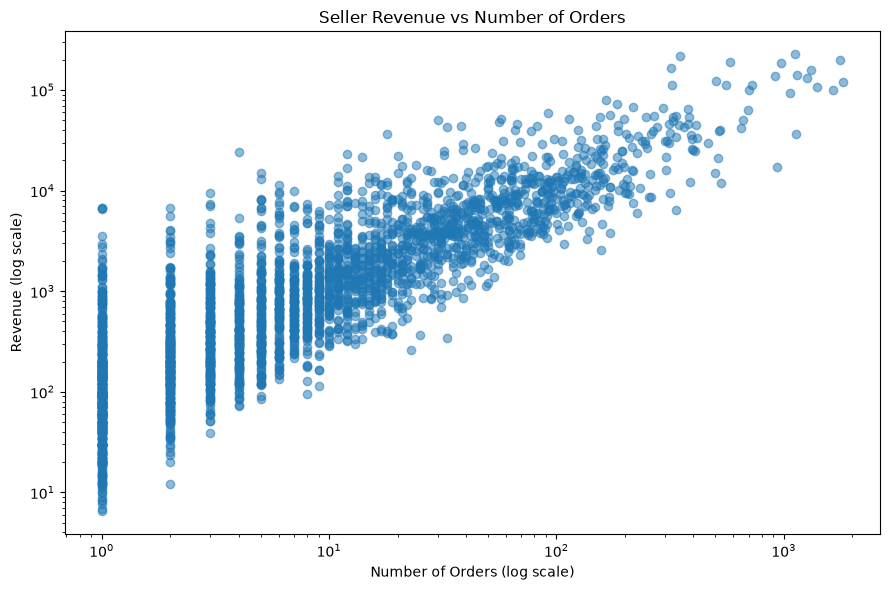

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    seller_performance["orders"],
    seller_performance["revenue"],
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.title("Seller Revenue vs Number of Orders")
plt.xlabel("Number of Orders (log scale)")
plt.ylabel("Revenue (log scale)")

plt.tight_layout()
plt.show()

## Key Findings

### Seller Revenue Concentration

Revenue is concentrated among a relatively small share of sellers. The top 1 seller accounts for 1.72% of total revenue, while the top 10 and top 25 sellers account for 13.27% and 23.81%, respectively.

This indicates that a relatively small group of sellers contributes a substantial share of marketplace revenue, although the business is not highly dependent on a single seller.

### Seller Revenue and Order Volume

Seller revenue is strongly associated with order volume, with a correlation of 0.80. However, the relationship is not perfect, indicating that order value also contributes to differences in seller revenue.